In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("C:\AIML\Projects\india_housing_prices.csv")

In [4]:
df.drop('ID',axis=1,inplace=True)

In [5]:
df['Locality']=df['Locality'].str.replace("Locality_","",regex=False)

In [6]:
df['Price_in_Lakhs']=df['Price_in_Lakhs']*100000

In [7]:
df['Price_per_SqFt']=df['Price_per_SqFt']*100000

In [8]:
data=df['Amenities'].str.get_dummies(sep=', ')
df=pd.concat([df,data],axis=1)
df.head()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Security,Amenities,Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,Tamil Nadu,Chennai,84,Apartment,1,4740,48976000.0,10000.0,1990,Furnished,...,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,1,1,1,1,1
1,Maharashtra,Pune,490,Independent House,3,2364,19552000.0,8000.0,2008,Unfurnished,...,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,1,1,1,1,1
2,Punjab,Ludhiana,167,Apartment,2,3642,18379000.0,5000.0,1997,Semi-furnished,...,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,1,0,1,1,1
3,Rajasthan,Jodhpur,393,Independent House,2,2741,30029000.0,11000.0,1991,Furnished,...,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,1,1,1,1,1
4,Rajasthan,Jaipur,466,Villa,4,4823,18290000.0,4000.0,2002,Semi-furnished,...,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,1,1,1,1,1


In [10]:
df['Total_Amenities']=df[['Clubhouse','Garden','Gym','Playground','Pool']].sum(axis=1)

Exploratory Data Analysis (EDA)

1–5: Price & Size Analysis

1. What is the distribution of property prices?

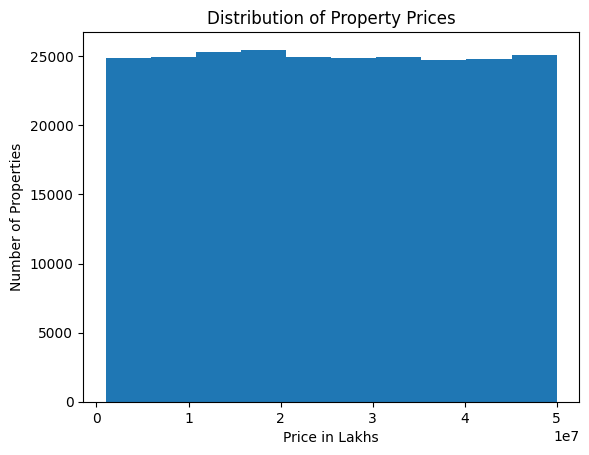

In [25]:
df['Price_in_Lakhs'].describe()
plt.hist(df['Price_in_Lakhs'])
plt.xlabel("Price in Lakhs")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Prices")
plt.show()

2. What is the distribution of property sizes?

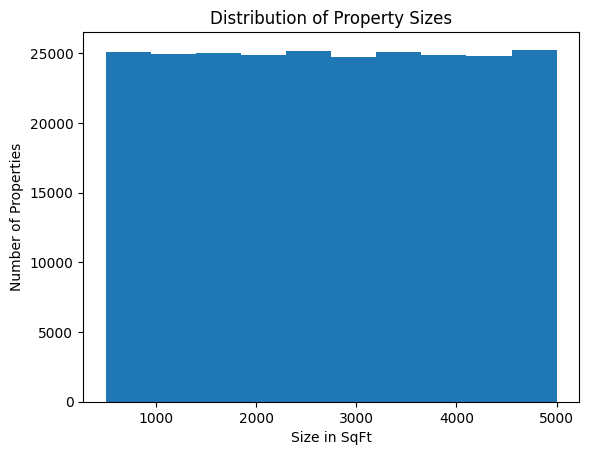

In [26]:
df['Size_in_SqFt'].describe()
plt.hist(df['Size_in_SqFt'])
plt.xlabel("Size in SqFt")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Sizes")
plt.show()

3. How does the price per sq ft vary by property type?

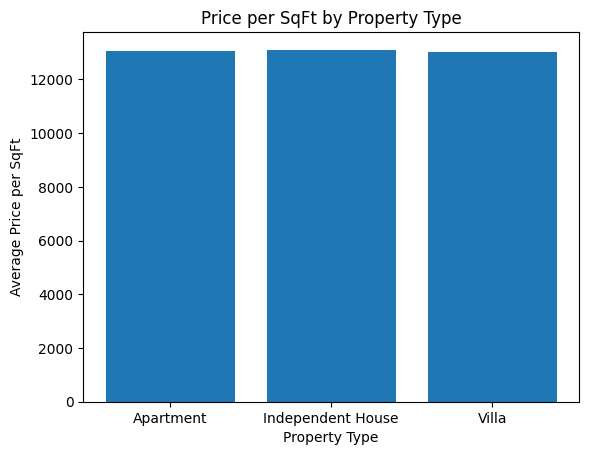

In [27]:
avg=df.groupby('Property_Type')['Price_per_SqFt'].mean()
plt.bar(avg.index,avg.values)
plt.xlabel("Property Type")
plt.ylabel("Average Price per SqFt")
plt.title("Price per SqFt by Property Type")
plt.show()

4. Is there a relationship between property size and price?

Correlation:  -0.0025285467925389065


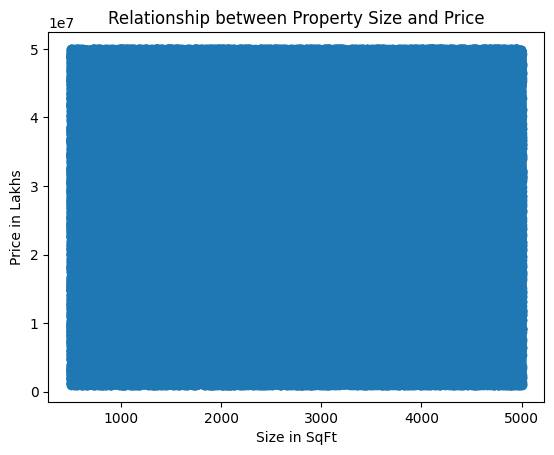

In [28]:
a=df['Size_in_SqFt'].corr(df['Price_in_Lakhs'])
print("Correlation: ",a)
plt.scatter(df['Size_in_SqFt'],df['Price_in_Lakhs'])
plt.xlabel("Size in SqFt")
plt.ylabel("Price in Lakhs")
plt.title("Relationship between Property Size and Price")
plt.show()

5. Are there any outliers in price per sq ft or property size?

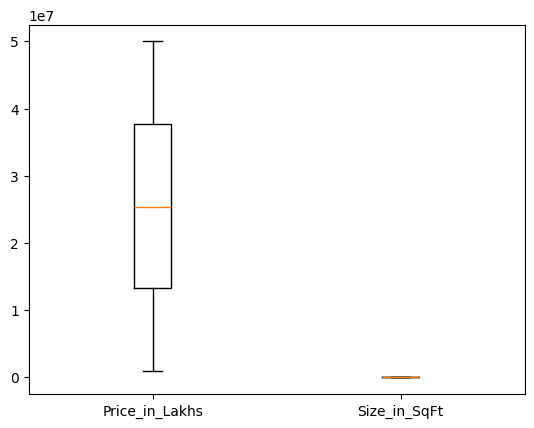

In [29]:
plt.boxplot([df['Price_in_Lakhs'],df['Size_in_SqFt']])
plt.xticks([1,2],['Price_in_Lakhs','Size_in_SqFt'])
plt.show()

6–10: Location-based Analysis

6. What is the average price per sq ft by state?


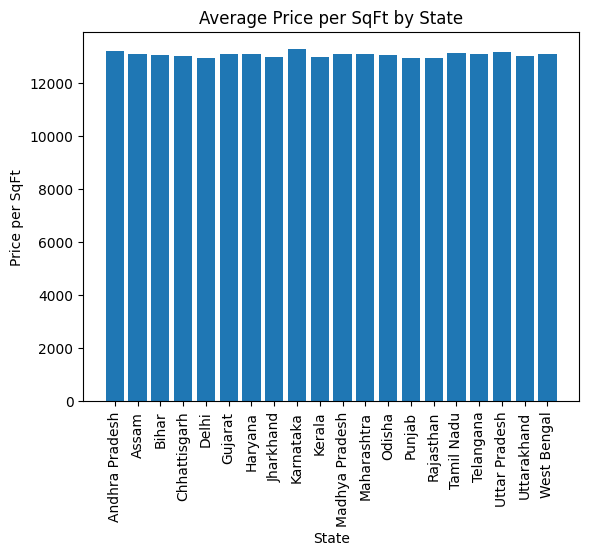

In [30]:
avg=df.groupby('State')['Price_per_SqFt'].mean()
# print(avg)
plt.bar(avg.index,avg.values)
plt.xlabel("State")
plt.ylabel("Price per SqFt")
plt.xticks(rotation=90)
plt.title("Average Price per SqFt by State")
plt.show()

7. What is the average property price by city?

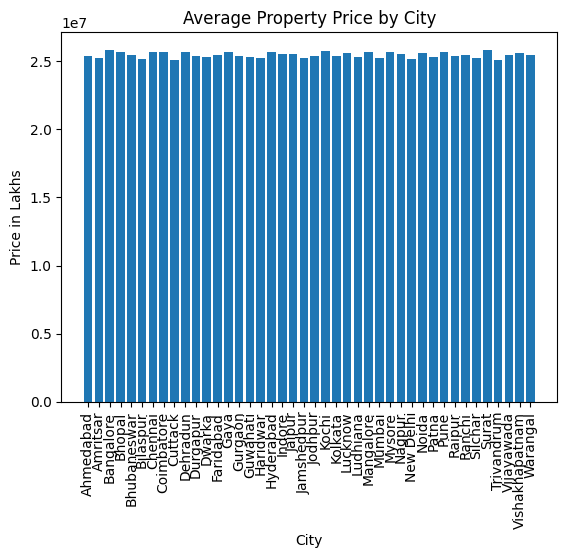

In [31]:
plt.figure()
avg=df.groupby('City')['Price_in_Lakhs'].mean()
plt.bar(avg.index,avg.values)
plt.xlabel("City")
plt.ylabel("Price in Lakhs")
plt.title("Average Property Price by City")
plt.xticks(rotation=90)
plt.show()


8. What is the median age of properties by locality?

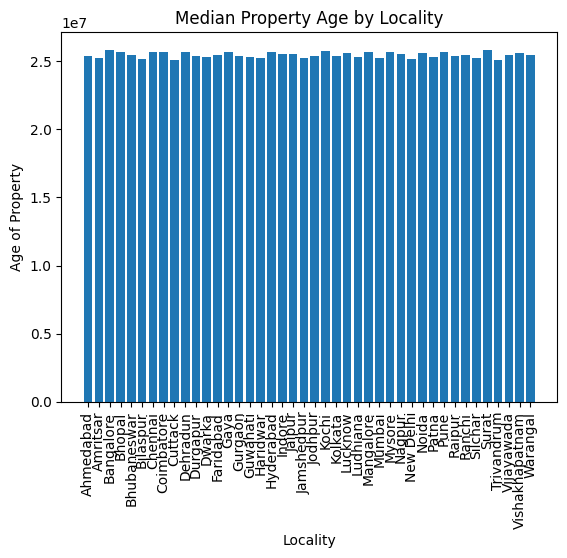

In [32]:
age=df.groupby('Locality')['Age_of_Property'].median()
plt.figure()
plt.bar(avg.index,avg.values)
plt.xlabel("Locality")
plt.ylabel("Age of Property")
plt.title("Median Property Age by Locality")
plt.xticks(rotation=90)
plt.show()

9. How is BHK distributed across cities?

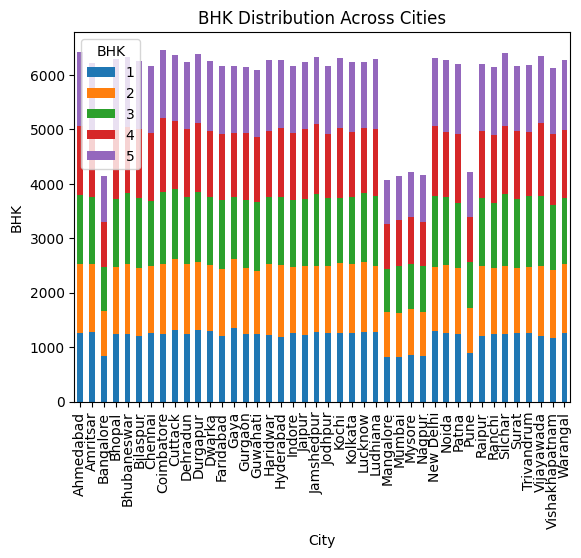

In [33]:
a=df.groupby(['City','BHK'])['BHK'].count().unstack()
a.plot(kind='bar',stacked=True)
plt.xlabel("City")
plt.ylabel("BHK")
plt.title("BHK Distribution Across Cities")
plt.xticks(rotation=90)
plt.show()

10. What are the price trends for the top 5 most expensive localities?

Locality
207    15214.132762
416    14786.610879
246    14578.431373
359    14468.750000
387    14439.834025
Name: Price_per_SqFt, dtype: float64


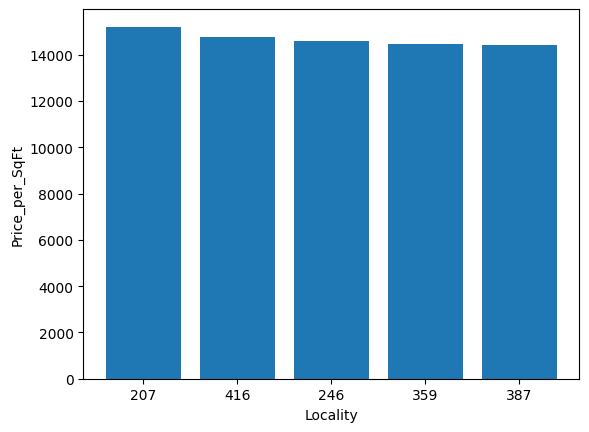

In [34]:
# 
top = df.groupby('Locality')['Price_per_SqFt'] \
    .mean()\
    .sort_values(ascending=False)\
    .head()
print(top)
plt.bar(top.index,top.values)
plt.xlabel("Locality")
plt.ylabel("Price_per_SqFt")
plt.title("")
plt.show()

11–15: Feature Relationship & Correlation

 11. How are numeric features correlated with each other?


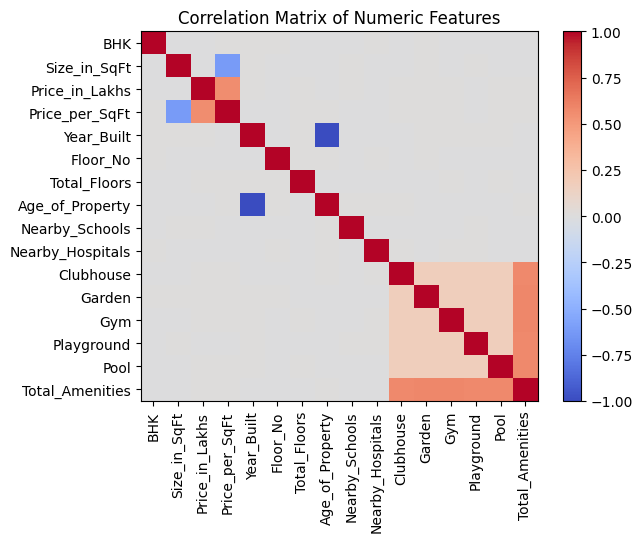

In [35]:
num=df.select_dtypes(['int64','float64'])
a=num.corr()
plt.imshow(a,cmap='coolwarm',aspect='auto')
plt.colorbar()
plt.xticks(range(len(a.columns)),a.columns,rotation=90)
plt.yticks(range(len(a.columns)),a.columns)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

12. How do nearby schools relate to price per sq ft?

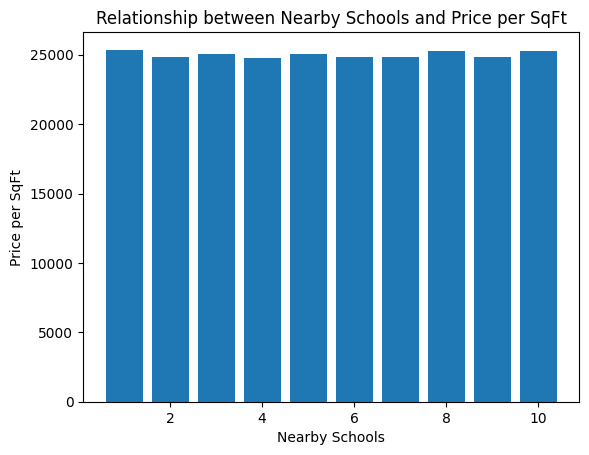

In [36]:
price=df.groupby('Nearby_Schools')['Price_per_SqFt'].count()
plt.bar(price.index,price.values)
plt.xlabel("Nearby Schools")
plt.ylabel("Price per SqFt")
plt.title("Relationship between Nearby Schools and Price per SqFt")
plt.show()

13. How do nearby hospitals relate to price per sq ft?

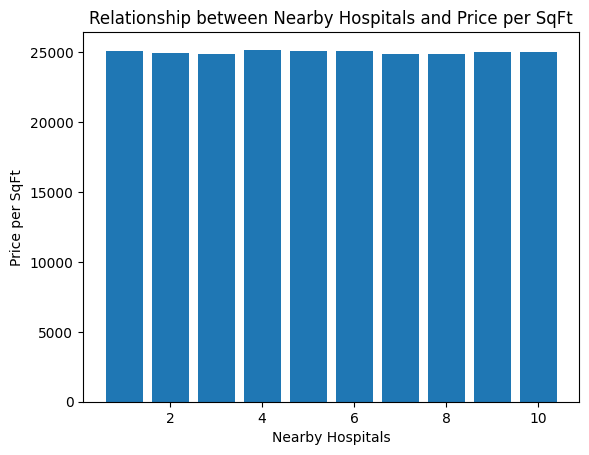

In [37]:
price=df.groupby('Nearby_Hospitals')['Price_per_SqFt'].count()
plt.bar(price.index,price.values)
plt.xlabel("Nearby Hospitals")
plt.ylabel("Price per SqFt")
plt.title("Relationship between Nearby Hospitals and Price per SqFt")
plt.show()

14. How does price vary by furnished status?

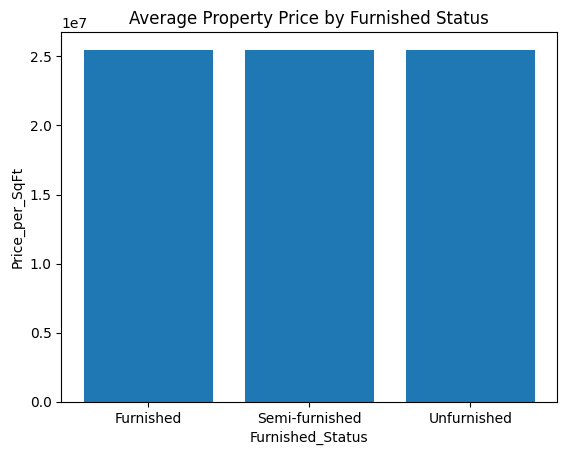

In [38]:
price=df.groupby('Furnished_Status')['Price_in_Lakhs'].mean()
plt.bar(price.index,price.values)
plt.xlabel("Furnished_Status")
plt.ylabel("Price_per_SqFt")
plt.title("Average Property Price by Furnished Status")
plt.show()

15.How does price per sq ft vary by property facing direction?

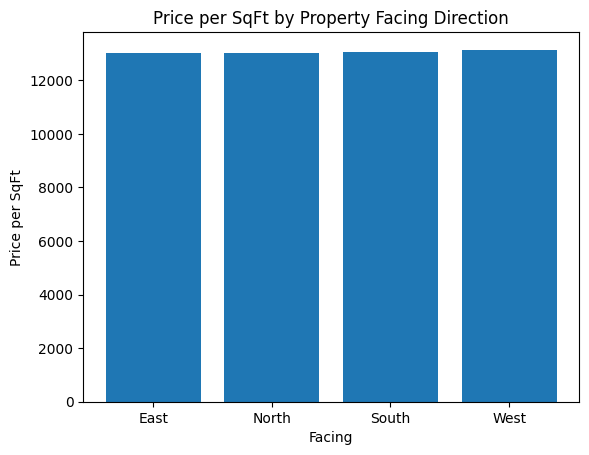

In [39]:
price=df.groupby('Facing')['Price_per_SqFt'].mean()
plt.bar(price.index,price.values)
plt.xlabel("Facing")
plt.ylabel("Price per SqFt")
plt.title("Price per SqFt by Property Facing Direction")
plt.show()

16–20: Investment / Amenities / Ownership Analysis

 16. How many properties belong to each owner type?


Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64


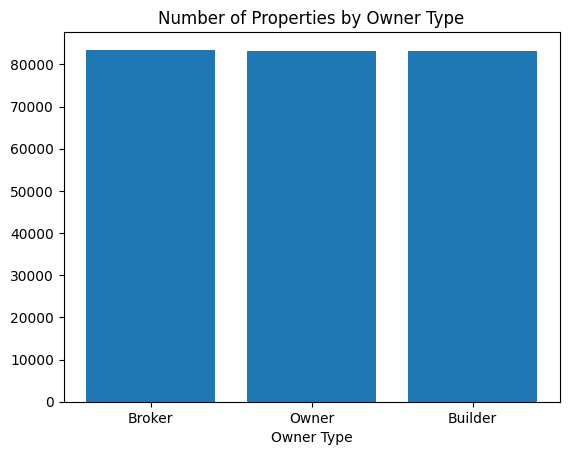

In [40]:
prop=df['Owner_Type'].value_counts()
print(prop)
plt.bar(prop.index,prop.values)
plt.xlabel("Owner Type")
plt.title("Number of Properties by Owner Type")
plt.show()

17. How many properties are available under each availability status?


Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64


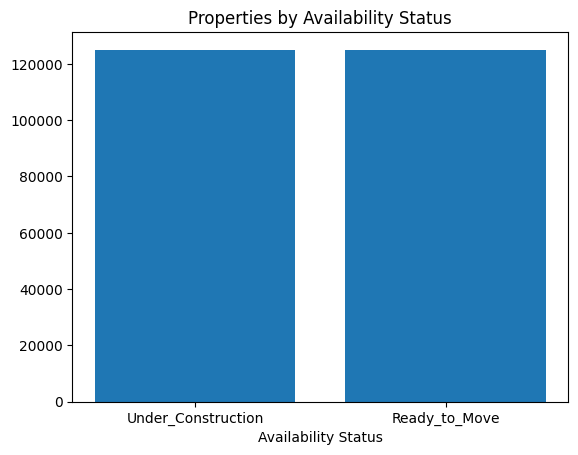

In [41]:
prop=df['Availability_Status'].value_counts()
print(prop)
plt.figure()
plt.bar(prop.index,prop.values)
plt.xlabel("Availability Status")
plt.title("Properties by Availability Status")
plt.show()

18. Does parking space affect property price?

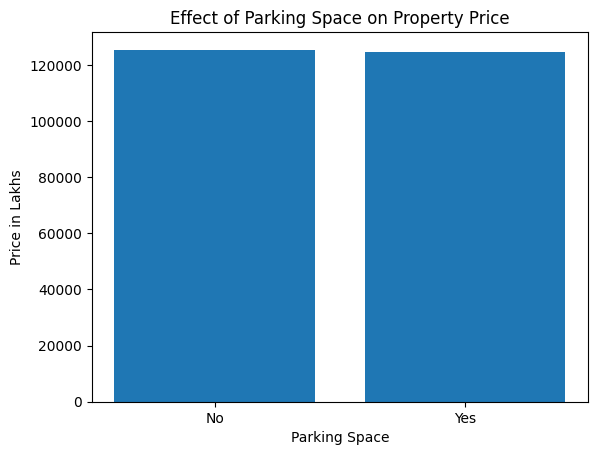

In [42]:
park=df.groupby('Parking_Space')['Price_in_Lakhs'].count()
plt.figure()
plt.bar(park.index,park.values)
plt.xlabel("Parking Space")
plt.ylabel("Price in Lakhs")
plt.title("Effect of Parking Space on Property Price")
plt.show()

19. How do amenities affect price per sq ft?

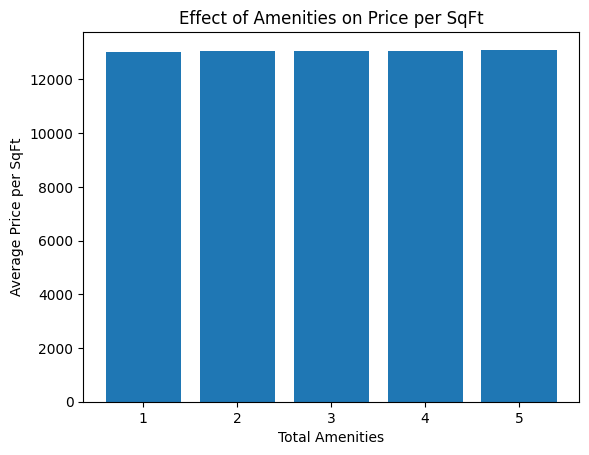

In [23]:
price=df.groupby('Total_Amenities')['Price_per_SqFt'].mean()
plt.bar(price.index,price.values)
plt.xlabel("Total Amenities")
plt.ylabel("Average Price per SqFt")
plt.title("Effect of Amenities on Price per SqFt")
plt.show()

20. How does public transport accessibility relate to price per sq ft or investment potential?

Public_Transport_Accessibility
High      83705
Low       83287
Medium    83008
Name: Price_per_SqFt, dtype: int64


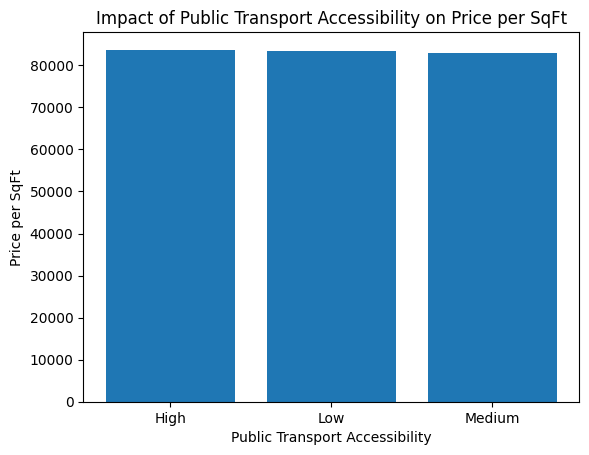

In [44]:
price=df.groupby('Public_Transport_Accessibility')['Price_per_SqFt'].count()
print(price)
plt.bar(price.index,price.values)
plt.xlabel("Public Transport Accessibility")
plt.ylabel("Price per SqFt")
plt.title("Impact of Public Transport Accessibility on Price per SqFt")
plt.show()